# Recreate Optimization Plots from Saved Results

This notebook regenerates the plots from the **Plotting** section of
`Run_Simulations_Final.ipynb` **without re-running the simulation** — it
loads the pre-computed CSVs in `../results/` and calls the same plotting
functions.

**Inputs** (in `../results/`):
- `vax_hurts_region_seeding.csv` &rarr; `hurts_df`
- `bo_results_fixed_params_seeding.csv` &rarr; `df_results`

**Outputs** (written to `../results/`): `vax_hurts_3d_plot.png`,
`vax_hurts_delta_auc_3d_plot.png`, `delta_prop_deaths_comparison.png`.

In [1]:
# --- Imports (plotting only; no simulation framework needed) ---
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm

dump_path = "../results/"
os.makedirs(dump_path, exist_ok=True)
print("Results directory:", dump_path)

Results directory: ../results/


## Plotting Functions

Copied verbatim from the simulation notebook so the output is identical.

In [2]:
# --- Plotting ---
def plot_3d_vax_hurts(df_results, filepath=None, title='Region Where Vaccination Increased Deaths'):
    df_results['actual_diff'] = -df_results['vax_harm_score']
    hurts_df = df_results[df_results['actual_diff'] > 0]

    if hurts_df.empty:
        print("No harmful vaccination outcomes found. Skipping 3D plot.")
        return

    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(111, projection='3d')
    x, y, z = hurts_df['death_prob'], hurts_df['vax_effect'], hurts_df['viral_age_effect']
    harm = hurts_df['actual_diff']
    norm = mcolors.Normalize(vmin=harm.min(), vmax=harm.max())
    colors = cm.Reds(norm(harm))

    ax.scatter(x, y, z, c=colors, marker='o', alpha=0.9)
    ax.set_xlabel('Death Probability')
    ax.set_ylabel('Vaccine Effectiveness')
    ax.set_zlabel('Viral Age Effect')
    ax.set_title(title)

    mappable = cm.ScalarMappable(norm=norm, cmap=cm.Reds)
    mappable.set_array(harm)
    cbar = plt.colorbar(mappable, ax=ax, pad=0.1)
    cbar.set_label('Vaccination Harm (Δ deaths)')

    plt.tight_layout()
    filepath = filepath or dump_path + "vax_hurts_3d_plot.png"
    plt.savefig(filepath, dpi=300)
    print(f"Plot saved to {filepath}")
    plt.show()


def plot_3d_delta_auc(df_results, filepath=None, title='Region Where Vaccination Increased Infection AUC'):
    auc_hurts_df = df_results[df_results['delta_auc'] > 0]

    if auc_hurts_df.empty:
        print("No harmful vaccination outcomes found. Skipping 3D plot.")
        return

    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(111, projection='3d')
    x, y, z = auc_hurts_df['death_prob'], auc_hurts_df['vax_effect'], auc_hurts_df['viral_age_effect']
    harm = auc_hurts_df['delta_auc']
    norm = mcolors.Normalize(vmin=harm.min(), vmax=harm.max())
    colors = cm.Reds(norm(harm))

    ax.scatter(x, y, z, c=colors, marker='o', alpha=0.9)
    ax.set_xlabel('Death Probability')
    ax.set_ylabel('Vaccine Effectiveness')
    ax.set_zlabel('Viral Age Effect')
    ax.set_title(title)

    mappable = cm.ScalarMappable(norm=norm, cmap=cm.Reds)
    mappable.set_array(harm)
    cbar = plt.colorbar(mappable, ax=ax, pad=0.1)
    cbar.set_label('Vaccination Harm (Δ Infection AUC)')

    plt.tight_layout()
    filepath = filepath or dump_path + "vax_hurts_delta_auc_3d_plot.png"
    plt.savefig(filepath, dpi=300)
    print(f"Plot saved to {filepath}")
    plt.show()


def plot_dead_delta_comparison(df):
    """
    Generates a scatter plot comparing non-vulnerable and vulnerable
    death proportion deltas.
    """
    plt.figure(figsize=(8, 6))
    plt.scatter(df['non_vul_proportion_dead_delta'],
                df['vulnerable_proportion_dead_delta'],
                alpha=0.6)

    # Zero reference lines
    plt.axhline(0, color='grey', linestyle='--', linewidth=1)
    plt.axvline(0, color='grey', linestyle='--', linewidth=1)

    # Labels and title
    plt.xlabel('Non-vulnerable Dead Delta')
    plt.ylabel('Vulnerable Dead Delta')
    plt.title('Comparison of Death Deltas\n(Non-vulnerable vs Vulnerable)')

    # Equal delta reference line
    lims = [
        min(df['non_vul_proportion_dead_delta'].min(), df['vulnerable_proportion_dead_delta'].min()),
        max(df['non_vul_proportion_dead_delta'].max(), df['vulnerable_proportion_dead_delta'].max()),
    ]
    plt.plot(lims, lims, 'r--', alpha=0.7, label='Equal Deltas')

    plt.legend()
    plt.tight_layout()
    filepath = dump_path + "delta_prop_deaths_comparison.png"
    plt.savefig(filepath, dpi=300)
    print(f"Plot saved to {filepath}")
    plt.show()

## Load Results

In [3]:
hurts_df = pd.read_csv(dump_path + 'vax_hurts_region_seeding.csv')
df_results = pd.read_csv(dump_path + 'bo_results_fixed_params_seeding.csv')

print("Viral age effect stats:")
print(hurts_df['viral_age_effect'].describe())
print("Min value in viral_age_effect:", hurts_df['viral_age_effect'].min())

Viral age effect stats:
count    437.000000
mean       0.347376
std        0.242731
min        0.100009
25%        0.111653
50%        0.248504
75%        0.537441
max        0.899405
Name: viral_age_effect, dtype: float64
Min value in viral_age_effect: 0.1000086829078923


## Plotting

Plot saved to ../results/vax_hurts_3d_plot.png


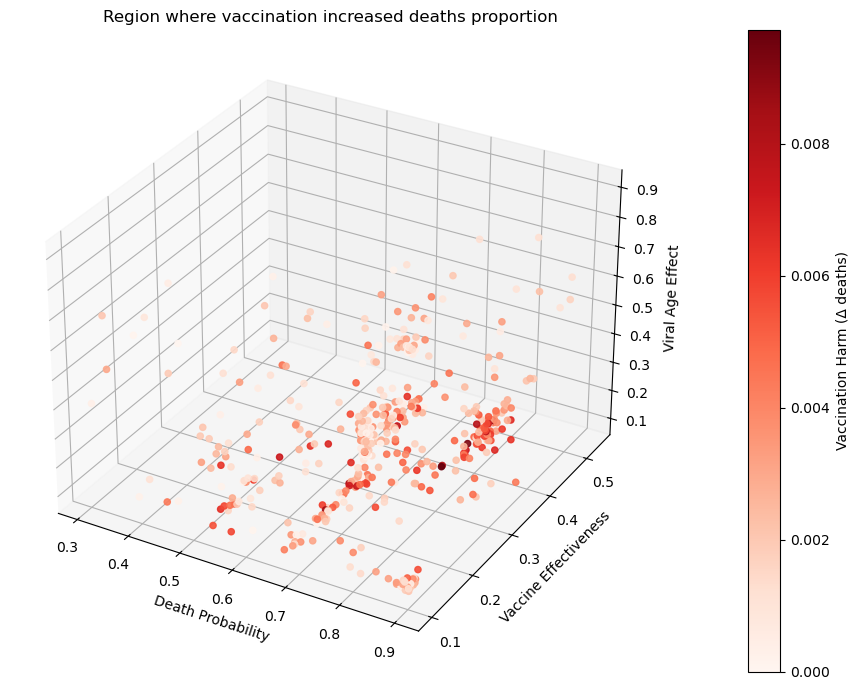

Plot saved to ../results/vax_hurts_delta_auc_3d_plot.png


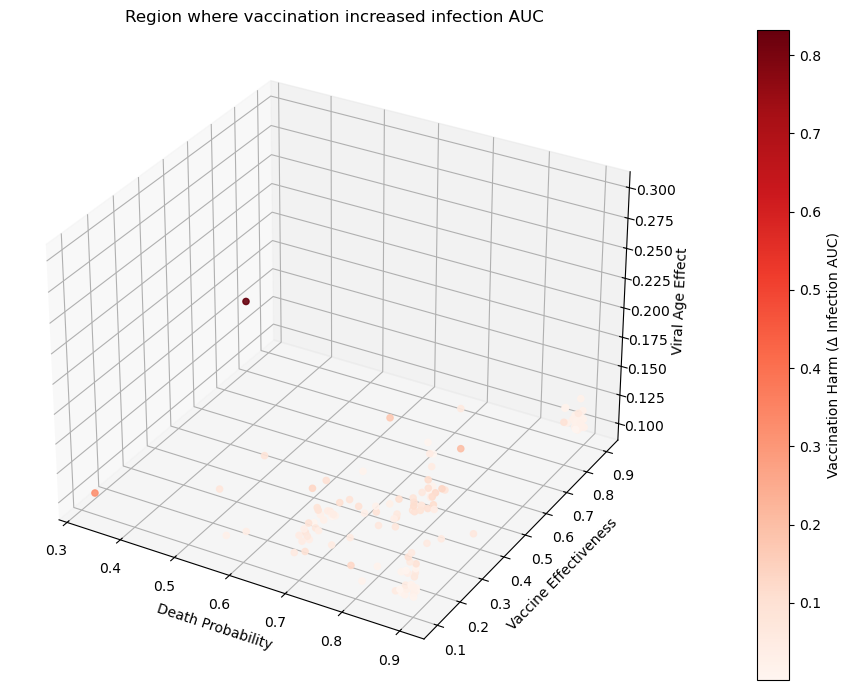

Plot saved to ../results/vax_hurts_delta_auc_3d_plot.png


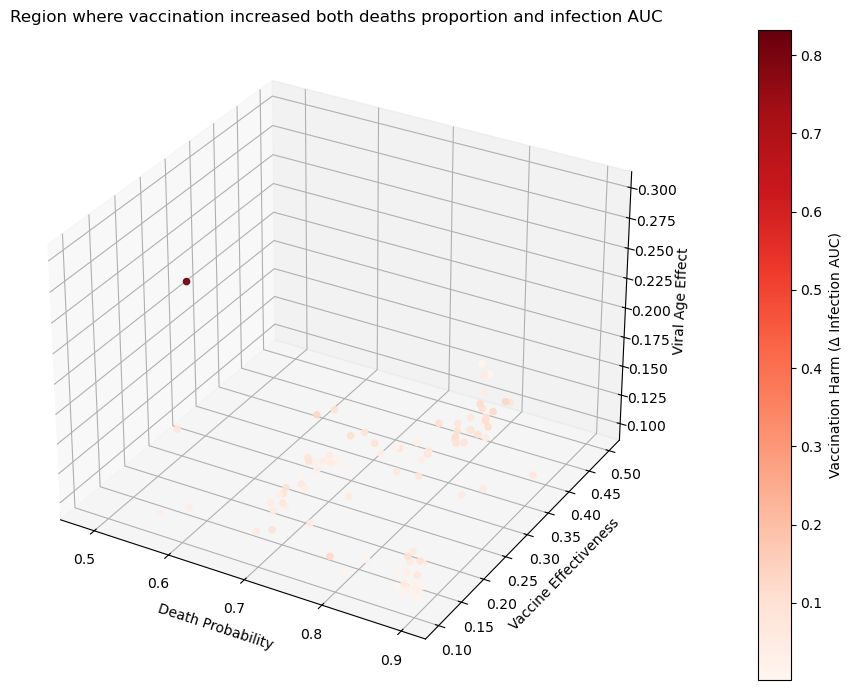

Plot saved to ../results/delta_prop_deaths_comparison.png


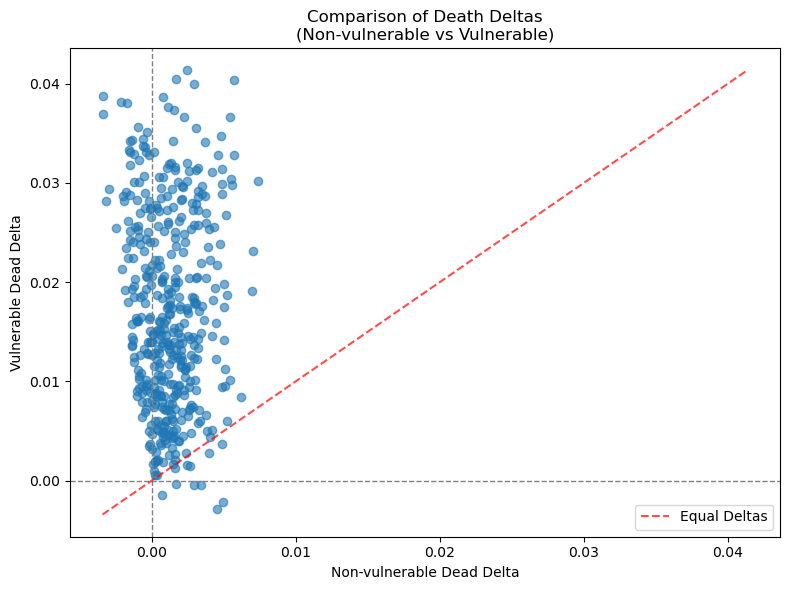

Plot saved to ../results/delta_prop_deaths_comparison.png


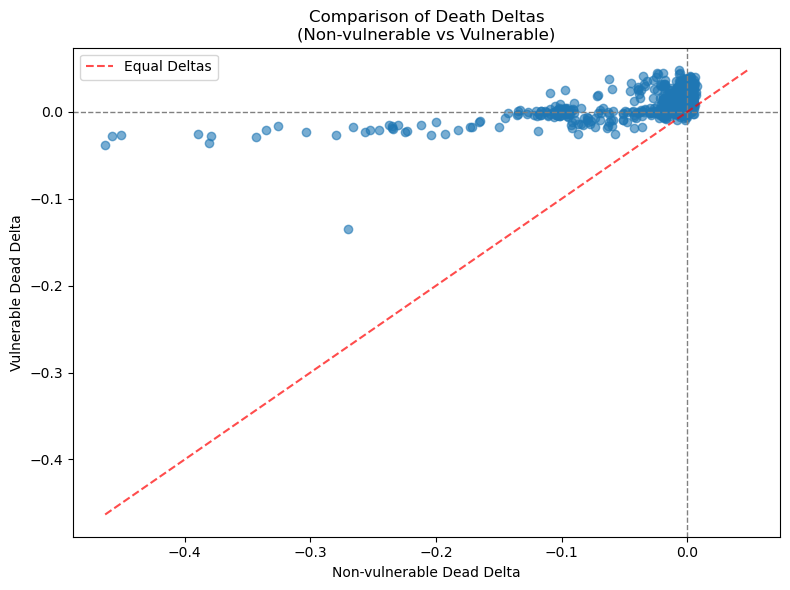

In [4]:
plot_3d_vax_hurts(hurts_df, title='Region where vaccination increased deaths proportion')
plot_3d_delta_auc(df_results, title='Region where vaccination increased infection AUC')
plot_3d_delta_auc(hurts_df, title='Region where vaccination increased both deaths proportion and infection AUC')
plot_dead_delta_comparison(hurts_df)
plot_dead_delta_comparison(df_results)